#### USGS Streamflow Data Retrieval Using `waterdata`

This tutorial demonstrates a workflow for working with USGS daily streamflow data using Python [`waterdata`](https://waterdata.usgs.gov/) API. It shows how to identify suitable streamflow monitoring stations near a point of interest, retrieve long, high‑quality discharge records, delineate the contributing watershed, and perform a basic hydrologic diagnostic.

Specifically, the tutorial:

*   Searches for nearby USGS streamflow stations and filters them based on **record length** and **data completeness**
*   Selects a representative watershed outlet and retrieves the full **multi‑decadal daily discharge time series**
*   Standardizes and exports the data for reuse and visualization
*   Delineates the upstream watershed and river network using NLDI services
*   Applies a **digital baseflow separation** method to partition total streamflow into quickflow and baseflow components
*   Computes the **Baseflow Index (BFI)** as a summary measure of groundwater contribution

The tutorial is standalone and can be executed directly. However, if you run this on your local machine, make sure to install all the necessary packages by running the following command

`pip install pandas numpy matplotlib shapely folium dataretrieval`

#### Obtaining and Using an API Key

**Important:** To avoid request limits and ensure reliable access to USGS Water Data APIs, obtain an API key. Register for a key and set it as an environment variable before making requests. This step is essential for large downloads, continuous data, and automated workflows. Its also instantaneous and does not take time to obtain your own API

1. Register for a USGS API key [here](https://api.waterdata.usgs.gov/signup/)
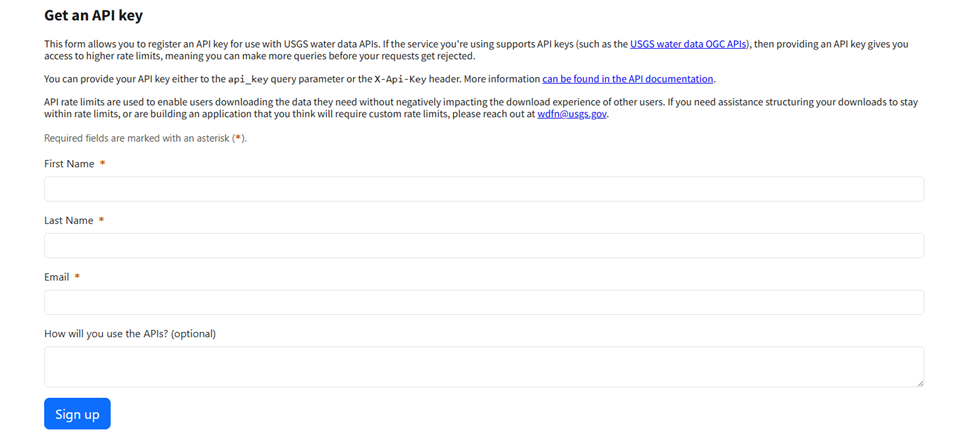

2. Set it as an environment variable

In [51]:
import os
os.environ["API_USGS_PAT"] = "33" #"your_api_key_here"

##### Define the search context
*   Defines a **point of interest (POI)** used to rank stations by proximity
*   Defines the **analysis window** (25 years)
*   Computes the total number of expected days — this is critical for measuring **true data gaps**

In [ ]:
poi = Point(-85.4943, 32.5981)
start_date, end_date = "2000-01-01", "2025-12-31"
expected_days = len(pd.date_range(start=start_date, end=end_date))

##### Identify nearby streamflow stations
*   Retrieves all **USGS streamflow stations** (`ST`) in Alabama
*   Computes distance from each station to the POI
*   Sorts stations so that **closest sites are evaluated first**

### Evaluate record length and data completeness
*   Stations are evaluated in **small batches** to avoid API overload
*   The loop continues until **5 qualifying stations** are found or all sites are scanned

For each station with data:

*   **Record length** is computed from the first to last observation
*   **Missing data percentage** is computed relative to the *full* date window
*   A station is accepted only if:
    *   Record length ≥ 15 years
    *   Missing data < 10%

This avoids stations with short but dense records or long but fragmented ones.

In [54]:
from dataretrieval import waterdata
from shapely.geometry import Point
import pandas as pd
import numpy as np

sites, _ = waterdata.get_monitoring_locations(state_name="Alabama", site_type_code="ST")
sites['distance'] = sites.geometry.distance(poi)
potential_sites = sites.sort_values('distance')

# The Discovery Loop
final_candidates = []
batch_size = 15
start_idx = 0

print(f"Goal: Find 5 stations with >15 yrs data and <10% gaps since {start_date}...")

while len(final_candidates) < 5 and start_idx < len(potential_sites):
    batch = potential_sites.iloc[start_idx : start_idx + batch_size]
    batch_ids = batch['monitoring_location_id'].tolist()
    
    try:
        df, _ = waterdata.get_daily(
            monitoring_location_id=batch_ids,
            parameter_code="00060",
            time=f"{start_date}/{end_date}"
        )
        
        if not df.empty:
            for sid, group in df.groupby('monitoring_location_id'):
                # TRUE Missingness: (Actual observations / Total days in 20-year window)
                # This counts both missing rows and rows where value is NaN
                actual_count = group['value'].count() 
                missing_pct = (1 - (actual_count / expected_days)) * 100
                
                # Calculate span for 'Years'
                years_span = (group['time'].max() - group['time'].min()).days / 365.25
                
                # Filter Logic: Must span 15+ years AND have <10% total gaps in the window
                if years_span >= 15 and missing_pct < 10:
                    meta = batch[batch['monitoring_location_id'] == sid].iloc[0]
                    final_candidates.append({
                        'Site_ID': sid,
                        'Name': meta['monitoring_location_name'],
                        'Geometry': meta['geometry'],
                        'County': meta['county_name'],
                        'Drainage_Area': meta['drainage_area'],
                        'Years_Span': round(years_span, 1),
                        'Gap_%': round(missing_pct, 1),
                        'Distance_Deg': round(meta['distance'], 4)
                    })
                    if len(final_candidates) >= 5: break
    except Exception:
        pass 
    
    start_idx += batch_size
    print(f"Scanned {start_idx} sites... Found {len(final_candidates)} candidates.")

results_df = pd.DataFrame(final_candidates)
print("\nFinal High-Quality Selection (00060 Discharge)")
results_df

Goal: Find 5 stations with >15 yrs data and <10% gaps since 2000-01-01...
Scanned 15 sites... Found 0 candidates.
Scanned 30 sites... Found 2 candidates.
Scanned 45 sites... Found 2 candidates.
Scanned 60 sites... Found 2 candidates.
Scanned 75 sites... Found 2 candidates.
Scanned 90 sites... Found 3 candidates.
Scanned 105 sites... Found 4 candidates.
Scanned 120 sites... Found 5 candidates.

Final High-Quality Selection (00060 Discharge)


,Site_ID,Name,Geometry,County,Drainage_Area,Years_Span,Gap_%,Distance_Deg
0,USGS-02418230,"SOUGAHATCHEE CREEK AT CO RD 188 NR LOACHAPOKA,...",POINT (-85.5880076053616 32.6268001450928),Lee County,71.3,26.0,0.2,0.0980
1,USGS-02419000,UPHAPEE CREEK NEAR TUSKEGEE AL,POINT (-85.69495709489374 32.47684012572784),Macon County,333.0,26.0,0.0,0.2345
2,USGS-02414715,"TALLAPOOSA RIVER NR NEW SITE, AL.(HORSESHOE BEND)",POINT (-85.73968041399858 32.977383146293526),Tallapoosa County,2058.0,26.0,0.1,0.4517
3,USGS-02414500,TALLAPOOSA RIVER AT WADLEY AL,POINT (-85.5607874599191 33.1167868401344),Randolph County,1675.0,26.0,0.5,0.5229
4,USGS-02342500,"UCHEE CREEK NEAR FORT MITCHELL, AL.",POINT (-85.0149310773485 32.3168146732565),Russell County,322.0,26.0,0.0,0.5558


#### Spatial Visualization of the Selected Watershed and Stream Network

After identifying a candidate streamflow station, this step visualizes its **spatial and hydrologic context** using an interactive map. The map displays the delineated upstream watershed, the associated river network, the selected outlet location, and a defined point of interest. We use the [Network Linked Data Index (NLDI)](https://waterdata.usgs.gov/blog/nldi-processes/) to:
- Delineate the upstream basin for the selected outlet station, and
- Retrieve the upstream river network for hydrologic context.

This visualization helps users to:

*   Verify that the selected station is correctly positioned as the **watershed outlet**
*   Confirm spatial consistency between the **point of interest**, **river network**, and **drainage basin**
*   Perform a quick qualitative check before proceeding with data extraction and analysis

Users can interact with the map by clicking on markers for additional information and toggling map layers on or off using the layer control in the upper‑right corner.

In [74]:
import folium
from dataretrieval import nldi

# 1. Selection & POI Definition
target_id = "USGS-02418230" # Sougahatchee Creek
poi_coords = [32.5981, -85.4943] # Auburn University [Lat, Lon]

# 2. Fetch NLDI Data
basin = nldi.get_basin(feature_source="nwissite", feature_id=target_id)
flowlines = nldi.get_flowlines(feature_source="nwissite", feature_id=target_id, 
                               navigation_mode="UT", distance=100)

# 3. Initialize Map with USGS Topo Basemap
m = folium.Map(location=[32.65, -85.45], zoom_start=11, tiles=None)

folium.TileLayer(
    tiles="https://basemap.nationalmap.gov/arcgis/rest/services/USGSTopo/MapServer/tile/{z}/{y}/{x}",
    attr="USGS The National Map",name="USGS Topo",overlay=False,control=True).add_to(m)

# 4. Add Watershed & Streams
# Bright Cyan for flowlines to pop against the Topo background
folium.GeoJson(
    basin.to_crs("EPSG:4326").__geo_interface__, name="Watershed Boundary",
    style_function=lambda x: {"color": "black", "weight": 4, "fillColor": "yellow", "fillOpacity": 0.1}
).add_to(m)

folium.GeoJson(
    flowlines.to_crs("EPSG:4326").__geo_interface__, name="River Network",
    style_function=lambda x: {"color": "blue", "weight": 1.5, "opacity": 1}
).add_to(m)

# 5. Mark POI and Outlet
# POI: Blue Info Icon
folium.Marker(
    location=poi_coords,
    popup="<b>Point of Interest</b><br>Auburn University",
    icon=folium.Icon(color="blue", icon="info-sign")
).add_to(m)

# OUTLET: Bright Red Star
# We extract coords from the first station in our results
selected = results_df.iloc[0]
outlet_coords = [selected['Geometry'].y, selected['Geometry'].x]
folium.Marker(
    location=outlet_coords,
    popup=f"<b>Watershed Outlet</b><br>{target_id}",
    icon=folium.Icon(color="red", icon="star", prefix="fa")
).add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
m

#### Retrieving and Preparing Daily Streamflow Data

Once a suitable outlet station has been identified, this step retrieves the **daily discharge time series** for that station using the USGS `waterdata` API. The request downloads daily mean streamflow (`00060`) over the predefined analysis period and returns both the data and site metadata.

The workflow then:

*   Renames and standardizes key fields for consistency
*   Converts time stamps to a proper datetime index
*   Optionally filters the record to retain only **USGS‑approved values**
*   Exports the full daily discharge series to a CSV file for reuse in downstream analyses

In [56]:
# 1. Use the ID from our previous successful match
target_id = selected['Site_ID'] # e.g., 'USGS-02418230'

# 2. Precise Download
# We request the full 25-year window for our target station
df_final, metadata = waterdata.get_daily(
    monitoring_location_id=target_id,
    parameter_code="00060",
    time=f"{start_date}/{end_date}"
)

# 3. Clean and Standardize the Dataframe
# The modern API returns 'value', 'approval_status', and 'time'
df_export = (
    df_final[['time', 'value', 'approval_status']]
    .rename(columns={'value': 'discharge_cfs', 'time': 'date'})
    .assign(date=pd.to_datetime(df_final['time']))
    .set_index('date')
    .sort_index()
)

# 4. Filter for 'Approved' data only (Optional but Professional)
# This removes 'Provisional' data which hasn't been fully verified by USGS
approved_only = df_export[df_export['approval_status'] == 'Approved']

print(f"--- Download Complete for {target_id} ---")
print(f"Total Records: {len(df_export)}")
print(f"Approved Records: {len(approved_only)}")

# 5. Export to CSV for use in other tools
file_name = f"{target_id}_daily_discharge.csv"
df_export.to_csv(file_name)
print(f"\nSuccessfully saved to: {file_name}")

df_export.head()

--- Download Complete for USGS-02418230 ---
Total Records: 9479
Approved Records: 9329

Successfully saved to: USGS-02418230_daily_discharge.csv


,discharge_cfs,approval_status
date,,
2000-01-01,33.0,Approved
2000-01-02,33.0,Approved
2000-01-03,33.0,Approved
2000-01-04,38.0,Approved
2000-01-05,37.0,Approved


#### A quick visualization of the downloaded data

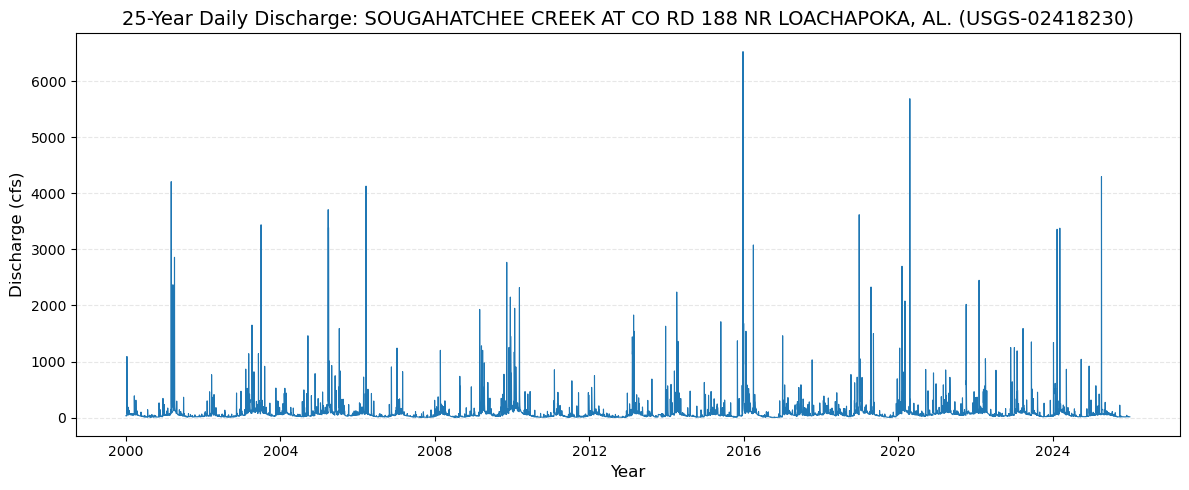

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(df_export.index, df_export['discharge_cfs'], color='tab:blue', lw=0.8)

plt.title(f"25-Year Daily Discharge: {selected['Name']} ({target_id})", fontsize=14)
plt.ylabel("Discharge (cfs)", fontsize=12)
plt.xlabel("Year", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

#### Baseflow Separation Using a Recursive Digital Filter

In this step, the daily discharge time series is partitioned into **quickflow** and **baseflow** components using a simple recursive digital filter. The method applies a smoothing parameter (`α = 0.925`) to estimate the short‑term flow response associated with runoff events, with baseflow obtained as the residual of total streamflow.

This approach is commonly used for **exploratory hydrologic analysis** and provides a practical way to assess relative groundwater contributions over time. The resulting separation is intended as a qualitative diagnostic rather than a physically explicit groundwater model.

A subset of the time series is plotted to visually inspect the separation between total streamflow and the estimated baseflow component.

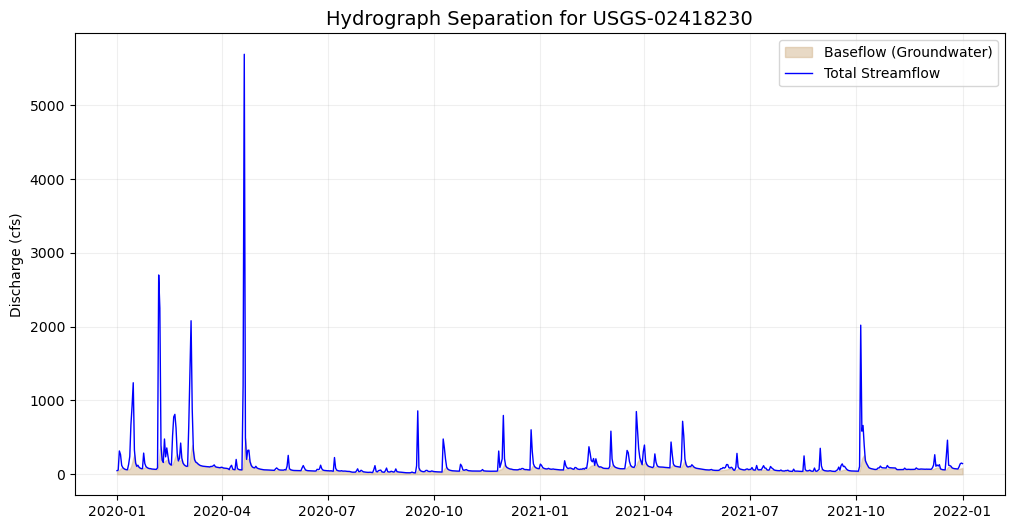

In [57]:
import numpy as np

# 1. Setup Filter Parameter (alpha typically 0.925 to 0.98)
alpha = 0.925
Q = df_export['discharge_cfs'].values
q = np.zeros(len(Q))

# 2. Apply Recursive Digital Filter
for t in range(1, len(Q)):
    # Calculate Quickflow component
    term1 = alpha * q[t-1]
    term2 = ((1 + alpha) / 2) * (Q[t] - Q[t-1])
    q[t] = term1 + term2
    
    # Constrain quickflow: cannot be negative or greater than total flow
    if q[t] < 0: q[t] = 0
    if q[t] > Q[t]: q[t] = Q[t]

# 3. Calculate Baseflow (Total - Quickflow)
df_export['quickflow'] = q
df_export['baseflow'] = df_export['discharge_cfs'] - q

# 4. Plot a specific window to see the separation (e.g., 2 years)
plt.figure(figsize=(12, 6))
subset = df_export.loc['2020-01-01':'2022-01-01']

plt.fill_between(subset.index, subset['baseflow'], color='tan', alpha=0.5, label='Baseflow (Groundwater)')
plt.plot(subset.index, subset['discharge_cfs'], color='blue', lw=1, label='Total Streamflow')

plt.title(f"Hydrograph Separation for {target_id}", fontsize=14)
plt.ylabel("Discharge (cfs)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

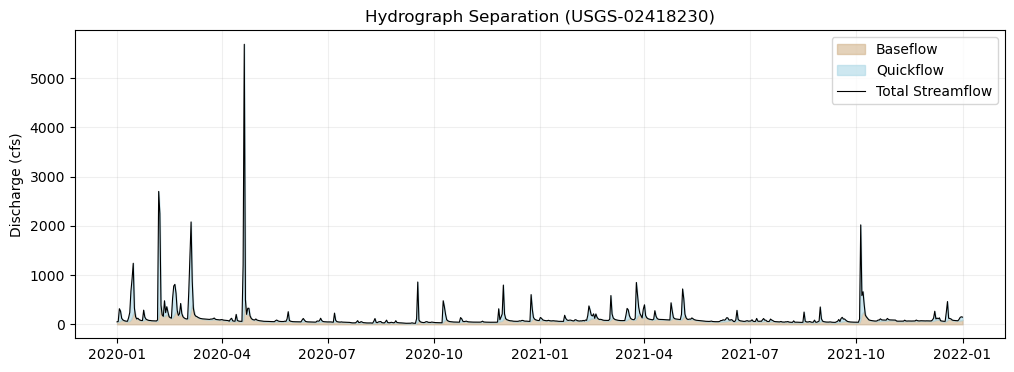

In [62]:
plt.figure(figsize=(12, 4))
subset = df_export.loc["2020-01-01":"2022-01-01"]

plt.fill_between(
    subset.index,
    subset["baseflow"],
    color="tan",
    alpha=0.6,
    label="Baseflow",
)

plt.fill_between(
    subset.index,
    subset["discharge_cfs"],
    subset["baseflow"],
    color="lightblue",
    alpha=0.6,
    label="Quickflow",
)

plt.plot(
    subset.index,
    subset["discharge_cfs"],
    color="black",
    lw=0.8,
    label="Total Streamflow",
)

plt.title(f"Hydrograph Separation ({target_id})")
plt.ylabel("Discharge (cfs)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

#### Baseflow Index (BFI) Calculation and Interpretation

In this step, we compute the **Baseflow Index (BFI)**, which summarizes the relative contribution of the **baseflow component** to total streamflow over the analysis period.

The BFI is calculated as the ratio of cumulative baseflow to cumulative total discharge:

$$
\text{BFI} = \frac{\sum \text{baseflow}}{\sum Q}
$$

where baseflow is the slowly varying component estimated using the recursive digital filter applied in the previous step.

This index provides a **dimensionless measure** of how dominant slow, sustained flow contributions are relative to event‑driven runoff. Because baseflow here is derived from a digital filter, the BFI should be interpreted as a **diagnostic indicator** rather than a direct measurement of groundwater discharge.

In practice, BFI is commonly used to:

*   Compare flow regime characteristics across watersheds
*   Assess seasonal or long‑term shifts in flow partitioning
*   Provide context for hydrologic modeling and watershed analysis

The reported value reflects the behavior of the streamflow time series **under the chosen filtering approach**, not a physically explicit separation of groundwater and surface water.

In [58]:
# 5. Calculate Baseflow Index (BFI)
bfi = (df_export['baseflow'].sum() / df_export['discharge_cfs'].sum()) * 100

print(f"Baseflow Index (BFI): {bfi:.1f}%")
print(
    "This indicates that approximately "
    f"{bfi:.1f}% of total streamflow is attributed to the "
    "slowly varying (baseflow) component, based on the applied digital filter."
)

Baseflow Index (BFI): 57.6%
This indicates that approximately 57.6% of total streamflow is attributed to the slowly varying (baseflow) component, based on the applied digital filter.


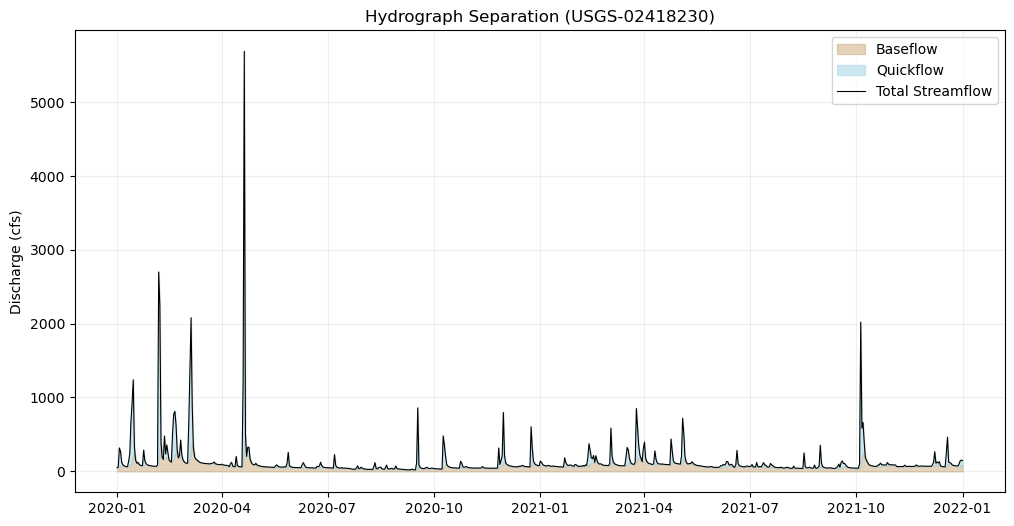

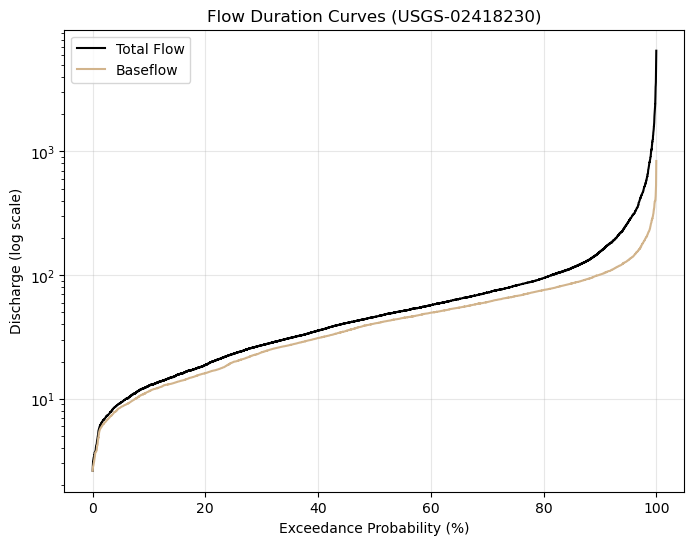

In [60]:
def flow_duration_curve(series):
    sorted_q = series.dropna().sort_values(ascending=False)
    exceedance = 100 * (sorted_q.rank(method="first") / len(sorted_q))
    return exceedance, sorted_q

p_q, q_q = flow_duration_curve(df_export["discharge_cfs"])
p_b, q_b = flow_duration_curve(df_export["baseflow"])

plt.figure(figsize=(8, 6))
plt.semilogy(p_q, q_q, label="Total Flow", color="black")
plt.semilogy(p_b, q_b, label="Baseflow", color="tan")

plt.xlabel("Exceedance Probability (%)")
plt.ylabel("Discharge (log scale)")
plt.title(f"Flow Duration Curves ({target_id})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()